In [1]:
import torch
import os
from pathlib import Path
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import StandardScaler
import h5py

In [2]:
import logging

logging.basicConfig(
    format='[%(asctime)s] %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S',
    level=logging.DEBUG
)

logger = logging.getLogger()
logger.info("hi")  # Same clean output

[2025-12-09 02:11:46] hi


In [3]:
# Constants
METADATA_PATH = "/home/harinit9/orcd/pool/musicgen-data-nokey/dataset_metadata.json"
ACT_BATCHED_PATH = Path("/home/wyf/orcd/pool/musicgen-activations-nokey/activations_pooled")
ACTS_BY_LAYER_PATH = Path("/home/wyf/orcd/pool/musicgen-activations-nokey/acts_by_layer")

In [4]:
with open(METADATA_PATH) as fin:
    metadata = json.load(fin)

In [5]:
class_labels = ["major", "minor"]

X_pooled = np.empty((1000, 2048))

def train_linear_probe(
    layer_idx: int,
    pca_dim: int,
    pooling_strat: str,
):
    acts = np.load(ACTS_BY_LAYER_PATH / f"layer_{layer_idx:02d}.npy")
    logger.info(f"Logistic regression on {layer_idx=}")

    # Pool across time
    logger.info("Pooling...")
    if pooling_strat == "max":
        np.max(acts, axis=1, out=X_pooled)
    else:
        np.mean(acts, axis=1, out=X_pooled)

    # Normalize per feature
    logger.info("Normalizing...")
    X_norm = StandardScaler().fit_transform(X_pooled)

    # Run PCA to reduce dimensionality
    from sklearn.decomposition import PCA

    logger.info("Running pca...")
    pca = PCA(n_components=pca_dim)
    X_pca = pca.fit_transform(X_pooled)     # shape: (1000, pca_dim)
    y_raw = np.array([
        class_labels.index(clip["key_info"]["mode"])
        for clip in metadata
    ])

    # Make train/test splits
    logger.info("Making test splits...")

    for _ in range(32):
        from sklearn.model_selection import train_test_split
        X_train, X_test, y_train, y_test = train_test_split(
            X_pca, y_raw,
            test_size=0.3,
            stratify=y_raw,
        )

        # Run logistic regression
        from sklearn.linear_model import LogisticRegression

        # logger.info("Fitting logistic regression...")
        reg = LogisticRegression()
        reg.fit(X_train, y_train)

        # Plot confusion matrix
        from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

        def evaluate(X, y):
            y_pred = reg.predict(X) >= 0.5

            cm = confusion_matrix(y, y_pred)
            # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
            # disp.plot()
            
            acc = accuracy_score(y, y_pred)
            return cm, acc
        
        # logger.info("Running eval...")
        _, train_acc = evaluate(X_train, y_train)
        _, test_acc = evaluate(X_test, y_test)

        print(f"[{layer_idx=}]  train_acc={train_acc * 100:.3f}%, test_acc={test_acc * 100:.3f}")
        yield train_acc, test_acc

In [6]:
records = []

In [7]:
# logger.setLevel("ERROR")
logger.setLevel("DEBUG")

for layer_idx in range(48):
    accs = list(train_linear_probe(layer_idx, 128, "max"))
    records.append((layer_idx, accs))

[2025-12-09 02:11:49] Logistic regression on layer_idx=0
[2025-12-09 02:11:49] Pooling...
[2025-12-09 02:11:49] Normalizing...
[2025-12-09 02:11:49] Running pca...
[2025-12-09 02:11:51] Making test splits...


[layer_idx=0]  train_acc=69.571%, test_acc=56.333
[layer_idx=0]  train_acc=71.286%, test_acc=52.000
[layer_idx=0]  train_acc=71.429%, test_acc=59.000
[layer_idx=0]  train_acc=69.286%, test_acc=53.000
[layer_idx=0]  train_acc=70.000%, test_acc=56.000
[layer_idx=0]  train_acc=72.571%, test_acc=51.333
[layer_idx=0]  train_acc=73.571%, test_acc=55.333
[layer_idx=0]  train_acc=73.429%, test_acc=53.333
[layer_idx=0]  train_acc=70.571%, test_acc=56.333
[layer_idx=0]  train_acc=70.571%, test_acc=57.667
[layer_idx=0]  train_acc=70.429%, test_acc=55.000
[layer_idx=0]  train_acc=70.857%, test_acc=54.333
[layer_idx=0]  train_acc=71.571%, test_acc=56.333
[layer_idx=0]  train_acc=70.714%, test_acc=50.000
[layer_idx=0]  train_acc=70.143%, test_acc=56.333
[layer_idx=0]  train_acc=70.429%, test_acc=55.667
[layer_idx=0]  train_acc=71.714%, test_acc=55.000
[layer_idx=0]  train_acc=71.143%, test_acc=55.667
[layer_idx=0]  train_acc=70.286%, test_acc=53.667
[layer_idx=0]  train_acc=70.286%, test_acc=57.333


[2025-12-09 02:11:55] Logistic regression on layer_idx=1
[2025-12-09 02:11:55] Pooling...
[2025-12-09 02:11:55] Normalizing...
[2025-12-09 02:11:55] Running pca...
[2025-12-09 02:11:56] Making test splits...


[layer_idx=1]  train_acc=70.714%, test_acc=53.000
[layer_idx=1]  train_acc=70.143%, test_acc=49.333
[layer_idx=1]  train_acc=70.286%, test_acc=60.333
[layer_idx=1]  train_acc=70.429%, test_acc=55.000
[layer_idx=1]  train_acc=70.143%, test_acc=57.000
[layer_idx=1]  train_acc=71.143%, test_acc=53.667
[layer_idx=1]  train_acc=69.571%, test_acc=59.667
[layer_idx=1]  train_acc=70.714%, test_acc=55.667
[layer_idx=1]  train_acc=72.143%, test_acc=58.000
[layer_idx=1]  train_acc=68.143%, test_acc=54.667
[layer_idx=1]  train_acc=69.000%, test_acc=56.333
[layer_idx=1]  train_acc=71.286%, test_acc=56.000
[layer_idx=1]  train_acc=70.429%, test_acc=58.333
[layer_idx=1]  train_acc=70.286%, test_acc=56.667
[layer_idx=1]  train_acc=70.286%, test_acc=59.333
[layer_idx=1]  train_acc=71.714%, test_acc=52.333
[layer_idx=1]  train_acc=70.000%, test_acc=57.333
[layer_idx=1]  train_acc=73.286%, test_acc=54.333
[layer_idx=1]  train_acc=72.000%, test_acc=57.333
[layer_idx=1]  train_acc=69.571%, test_acc=53.333


[2025-12-09 02:11:59] Logistic regression on layer_idx=2
[2025-12-09 02:11:59] Pooling...
[2025-12-09 02:11:59] Normalizing...
[2025-12-09 02:11:59] Running pca...
[2025-12-09 02:12:00] Making test splits...


...

[layer_idx=45]  train_acc=74.571%, test_acc=57.000
[layer_idx=45]  train_acc=73.429%, test_acc=57.000
[layer_idx=45]  train_acc=71.571%, test_acc=57.000
[layer_idx=45]  train_acc=73.714%, test_acc=54.000
[layer_idx=45]  train_acc=71.429%, test_acc=59.000
[layer_idx=45]  train_acc=71.286%, test_acc=59.000
[layer_idx=45]  train_acc=73.429%, test_acc=56.333
[layer_idx=45]  train_acc=72.143%, test_acc=51.667
[layer_idx=45]  train_acc=72.143%, test_acc=59.000
[layer_idx=45]  train_acc=71.714%, test_acc=58.333
[layer_idx=45]  train_acc=70.714%, test_acc=60.667
[layer_idx=45]  train_acc=74.571%, test_acc=58.000
[layer_idx=45]  train_acc=72.714%, test_acc=58.667
[layer_idx=45]  train_acc=72.429%, test_acc=55.000
[layer_idx=45]  train_acc=72.571%, test_acc=59.333
[layer_idx=45]  train_acc=74.286%, test_acc=52.333
[layer_idx=45]  train_acc=72.714%, test_acc=57.000
[layer_idx=45]  train_acc=73.429%, test_acc=59.667
[layer_idx=45]  train_acc=72.571%, test_acc=59.333
[layer_idx=45]  train_acc=72.14

[2025-12-09 02:16:12] Logistic regression on layer_idx=46
[2025-12-09 02:16:12] Pooling...
[2025-12-09 02:16:12] Normalizing...
[2025-12-09 02:16:12] Running pca...
[2025-12-09 02:16:13] Making test splits...


[layer_idx=46]  train_acc=70.429%, test_acc=54.000
[layer_idx=46]  train_acc=71.571%, test_acc=55.000
[layer_idx=46]  train_acc=69.714%, test_acc=56.667
[layer_idx=46]  train_acc=69.571%, test_acc=57.333
[layer_idx=46]  train_acc=71.857%, test_acc=57.000
[layer_idx=46]  train_acc=71.000%, test_acc=55.000
[layer_idx=46]  train_acc=73.143%, test_acc=55.000
[layer_idx=46]  train_acc=70.714%, test_acc=56.333
[layer_idx=46]  train_acc=69.286%, test_acc=59.000
[layer_idx=46]  train_acc=73.286%, test_acc=55.333
[layer_idx=46]  train_acc=72.286%, test_acc=55.667
[layer_idx=46]  train_acc=71.286%, test_acc=58.333
[layer_idx=46]  train_acc=74.286%, test_acc=50.333
[layer_idx=46]  train_acc=72.143%, test_acc=53.000
[layer_idx=46]  train_acc=71.286%, test_acc=56.000
[layer_idx=46]  train_acc=71.714%, test_acc=56.667
[layer_idx=46]  train_acc=72.000%, test_acc=55.667
[layer_idx=46]  train_acc=71.286%, test_acc=55.000
[layer_idx=46]  train_acc=70.857%, test_acc=55.000
[layer_idx=46]  train_acc=70.71

[2025-12-09 02:16:16] Logistic regression on layer_idx=47
[2025-12-09 02:16:16] Pooling...
[2025-12-09 02:16:16] Normalizing...
[2025-12-09 02:16:16] Running pca...
[2025-12-09 02:16:18] Making test splits...


[layer_idx=47]  train_acc=71.000%, test_acc=54.000
[layer_idx=47]  train_acc=73.286%, test_acc=56.000
[layer_idx=47]  train_acc=72.286%, test_acc=58.667
[layer_idx=47]  train_acc=75.000%, test_acc=59.000
[layer_idx=47]  train_acc=70.857%, test_acc=60.333
[layer_idx=47]  train_acc=72.143%, test_acc=59.667
[layer_idx=47]  train_acc=71.429%, test_acc=57.333
[layer_idx=47]  train_acc=73.286%, test_acc=53.667
[layer_idx=47]  train_acc=74.429%, test_acc=50.667
[layer_idx=47]  train_acc=72.286%, test_acc=64.000
[layer_idx=47]  train_acc=73.000%, test_acc=59.000
[layer_idx=47]  train_acc=73.143%, test_acc=55.667
[layer_idx=47]  train_acc=73.571%, test_acc=58.000
[layer_idx=47]  train_acc=70.714%, test_acc=58.000
[layer_idx=47]  train_acc=70.857%, test_acc=56.333
[layer_idx=47]  train_acc=73.429%, test_acc=59.667
[layer_idx=47]  train_acc=71.857%, test_acc=54.000
[layer_idx=47]  train_acc=70.714%, test_acc=57.667
[layer_idx=47]  train_acc=72.714%, test_acc=58.000
[layer_idx=47]  train_acc=72.28

In [8]:
train_acc = []
test_acc = []

for idx, samples in records:
    for train, test in samples:
        train_acc.append((idx, train))
        test_acc.append((idx, test))

print(records)

[(0, [(0.6957142857142857, 0.5633333333333334), (0.7128571428571429, 0.52), (0.7142857142857143, 0.59), (0.6928571428571428, 0.53), (0.7, 0.56), (0.7257142857142858, 0.5133333333333333), (0.7357142857142858, 0.5533333333333333), (0.7342857142857143, 0.5333333333333333), (0.7057142857142857, 0.5633333333333334), (0.7057142857142857, 0.5766666666666667), (0.7042857142857143, 0.55), (0.7085714285714285, 0.5433333333333333), (0.7157142857142857, 0.5633333333333334), (0.7071428571428572, 0.5), (0.7014285714285714, 0.5633333333333334), (0.7042857142857143, 0.5566666666666666), (0.7171428571428572, 0.55), (0.7114285714285714, 0.5566666666666666), (0.7028571428571428, 0.5366666666666666), (0.7028571428571428, 0.5733333333333334), (0.7328571428571429, 0.5233333333333333), (0.6942857142857143, 0.5933333333333334), (0.7071428571428572, 0.5466666666666666), (0.7171428571428572, 0.5566666666666666), (0.6928571428571428, 0.5533333333333333), (0.7, 0.5633333333333334), (0.7028571428571428, 0.54666666

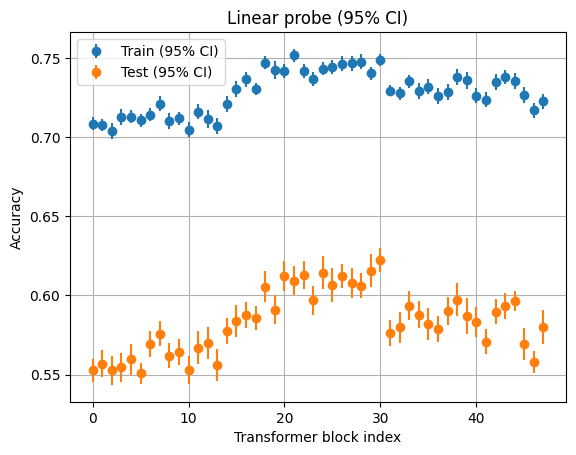

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy import stats

# Organize data by transformer block index
train_data = defaultdict(list)
test_data = defaultdict(list)

for idx, samples in records:
    for train, test in samples:
        train_data[idx].append(train)
        test_data[idx].append(test)

# Compute mean and 95% CI for each block
train_means = []
train_cis = []
test_means = []
test_cis = []
indices = sorted(train_data.keys())

for idx in indices:
    train_vals = np.array(train_data[idx])
    test_vals = np.array(test_data[idx])
    
    n_train = len(train_vals)
    n_test = len(test_vals)
    
    # Mean
    train_mean = np.mean(train_vals)
    test_mean = np.mean(test_vals)
    
    # 95% CI using t-distribution
    train_ci = stats.t.ppf(0.975, n_train-1) * np.std(train_vals, ddof=1) / np.sqrt(n_train)
    test_ci = stats.t.ppf(0.975, n_test-1) * np.std(test_vals, ddof=1) / np.sqrt(n_test)
    
    train_means.append(train_mean)
    train_cis.append(train_ci)
    test_means.append(test_mean)
    test_cis.append(test_ci)

logger.setLevel("INFO")

# Plot with 95% CI error bars
plt.errorbar(indices, train_means, yerr=train_cis, fmt='o', label="Train (95% CI)")
plt.errorbar(indices, test_means, yerr=test_cis, fmt='o', label="Test (95% CI)")
plt.xlabel("Transformer block index")
plt.ylabel("Accuracy")
plt.title("Linear probe (95% CI)")
plt.legend()
plt.grid()
plt.show()